# PROJECT SUBMISSION BY - VIVA BARANWAL

# LOAD AND CLEAN INITIAL DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/marketing_data.csv")

# Clean space from headers
df.columns = df.columns.str.strip()

# Clean income strings to numbers
df['Income'] = df['Income'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# Format date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%y')

# Fill missing income values dynamically
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.median()))

# FEATURE ENGINEERING & OUTLIER TREATMENT

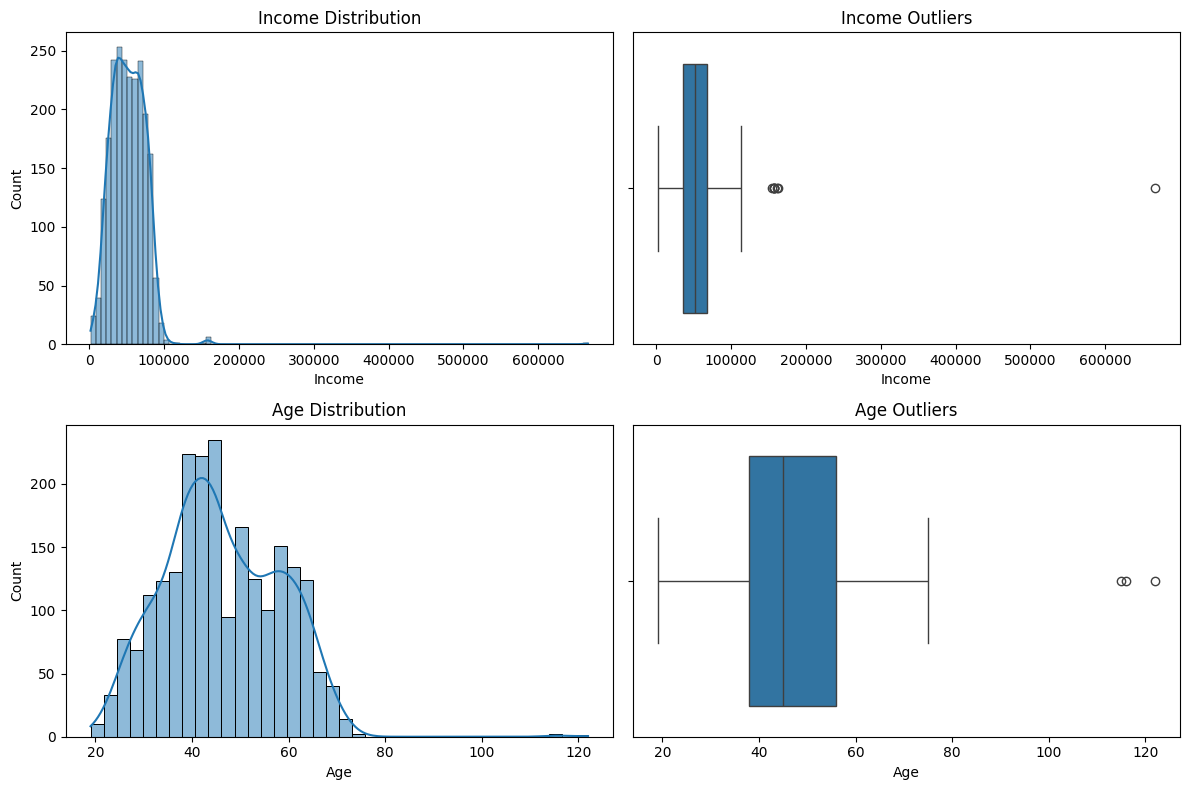

In [2]:
# 1. Create columns
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Age'] = 2015 - df['Year_Birth']

product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[product_cols].sum(axis=1)

purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# 2. Plot graphs
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Income'], kde=True, ax=axes[0, 0]).set(title='Income Distribution')
sns.boxplot(x=df['Income'], ax=axes[0, 1]).set(title='Income Outliers')
sns.histplot(df['Age'], kde=True, ax=axes[1, 0]).set(title='Age Distribution')
sns.boxplot(x=df['Age'], ax=axes[1, 1]).set(title='Age Outliers')
plt.tight_layout()
plt.show()

# 3. Cap Outliers
for col in ['Income', 'Age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.where(df[col] < (Q1 - 1.5 * IQR), Q1 - 1.5 * IQR, df[col])
    df[col] = np.where(df[col] > (Q3 + 1.5 * IQR), Q3 + 1.5 * IQR, df[col])

# ADVANCED CaATEGORICAL DATA CLEANING

In [3]:
# Clean Marital Status: Group obscure or solo categories into 'Single'
marital_map = {
    'Married': 'Married', 'Together': 'Together', 'Divorced': 'Divorced', 
    'Widow': 'Widow', 'Single': 'Single', 'Alone': 'Single', 
    'Absurd': 'Single', 'YOLO': 'Single'
}
df['Marital_Status'] = df['Marital_Status'].map(marital_map)

# Clean Education: Keep it clear and standardized
education_map = {
    'Graduation': 'Graduate', 'PhD': 'Postgraduate', 'Master': 'Postgraduate', 
    '2n Cycle': 'Undergraduate', 'Basic': 'Undergraduate'
}
df['Education'] = df['Education'].map(education_map)

print("Marital Status after cleaning:", df['Marital_Status'].unique())
print("Education after cleaning:", df['Education'].unique())

Marital Status after cleaning: <StringArray>
['Divorced', 'Single', 'Married', 'Together', 'Widow']
Length: 5, dtype: str
Education after cleaning: <StringArray>
['Graduate', 'Postgraduate', 'Undergraduate']
Length: 3, dtype: str


# CATEGORICAL ENCODING

In [4]:
# 1. Ordinal Encoding for Education (giving it a logical order)
edu_order = {'Undergraduate': 0, 'Graduate': 1, 'Postgraduate': 2}
df['Education_Encoded'] = df['Education'].map(edu_order)

# 2. One-Hot Encoding for Marital_Status and Country
# This creates separate 0 and 1 columns for each category
df_encoded = pd.get_dummies(df, columns=['Marital_Status', 'Country'], drop_first=True, dtype=int)

print("Encoding complete!")
print("New total columns in dataset:", df_encoded.shape[1])


Encoding complete!
New total columns in dataset: 42


# CORRELATION HEATMAP

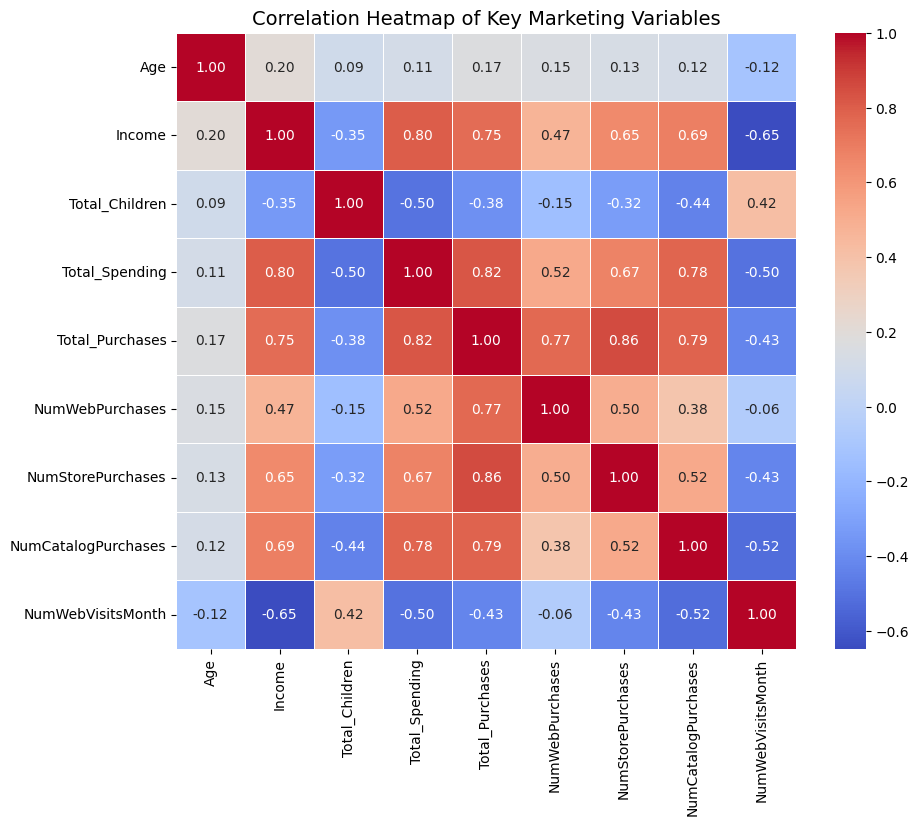

In [5]:
# Select the key columns we want to see relationships for
core_cols = ['Age', 'Income', 'Total_Children', 'Total_Spending', 'Total_Purchases', 
             'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth']

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[core_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Marketing Variables', fontsize=14)
plt.show()

# HYPOTHESIS TESTING

In [6]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.


In [7]:
from scipy import stats

print("=== STATISTICAL HYPOTHESIS TESTING RESULTS ===\n")

# Hypothesis 1: Older individuals prefer traditional in-store shopping.
# Test: Pearson Correlation between Age and NumStorePurchases
corr, p_val1 = stats.pearsonr(df_encoded['Age'], df_encoded['NumStorePurchases'])
print(f"Hypothesis 1 (Age vs Store): Correlation = {corr:.3f}, p-value = {p_val1:.3e}")
if p_val1 < 0.05 and corr > 0:
    print("Conclusion: Reject H0. Older individuals significantly prefer in-store shopping.\n")
else:
    print("Conclusion: Fail to reject H0. No significant positive relationship found.\n")

# Hypothesis 2: Customers with children lean toward online shopping.
# Test: Two-sample T-test (Has Children vs No Children Web Purchases)
has_kids = df_encoded[df_encoded['Total_Children'] > 0]['NumWebPurchases']
no_kids = df_encoded[df_encoded['Total_Children'] == 0]['NumWebPurchases']
t_stat2, p_val2 = stats.ttest_ind(has_kids, no_kids, equal_var=False)
print(f"Hypothesis 2 (Kids vs Online): T-statistic = {t_stat2:.3f}, p-value = {p_val2:.3e}")
if p_val2 < 0.05 and t_stat2 > 0:
    print("Conclusion: Reject H0. Customers with children shop online significantly more.\n")
else:
    print("Conclusion: Fail to reject H0. Having children does not significantly increase online shopping purchases.\n")

# Hypothesis 3: Physical store sales face cannibalization by alternative channels.
# Test: Correlation between Store Purchases and Web/Catalog Purchases
corr_web, p_web = stats.pearsonr(df_encoded['NumStorePurchases'], df_encoded['NumWebPurchases'])
corr_cat, p_cat = stats.pearsonr(df_encoded['NumStorePurchases'], df_encoded['NumCatalogPurchases'])
print(f"Hypothesis 3 (Cannibalization): Store vs Web Corr = {corr_web:.3f}, Store vs Catalog Corr = {corr_cat:.3f}")
if corr_web < 0 or corr_cat < 0:
    print("Conclusion: Evidence of cannibalization exists (negative correlation).\n")
else:
    print("Conclusion: No cannibalization. Sales channels show a positive correlation (they support each other).\n")

# Hypothesis 4: Does the United States significantly outperform the rest of the world in total purchase volumes?
# Test: Two-sample T-test (US vs Non-US Total Purchases)
us_col = [c for c in df_encoded.columns if 'US' in c]
if us_col:
    us_purchases = df_encoded[df_encoded[us_col[0]] == 1]['Total_Purchases']
    row_purchases = df_encoded[df_encoded[us_col[0]] == 0]['Total_Purchases']
    t_stat4, p_val4 = stats.ttest_ind(us_purchases, row_purchases, equal_var=False)
    print(f"Hypothesis 4 (US Performance): T-statistic = {t_stat4:.3f}, p-value = {p_val4:.3e}")
    if p_val4 < 0.05 and t_stat4 > 0:
        print("Conclusion: Reject H0. The US significantly outperforms the rest of the world in total purchase volumes.\n")
    else:
        print("Conclusion: Fail to reject H0. The US does not significantly outperform the rest of the world.\n")

=== STATISTICAL HYPOTHESIS TESTING RESULTS ===

Hypothesis 1 (Age vs Store): Correlation = 0.134, p-value = 1.690e-10
Conclusion: Reject H0. Older individuals significantly prefer in-store shopping.

Hypothesis 2 (Kids vs Online): T-statistic = -3.542, p-value = 4.108e-04
Conclusion: Fail to reject H0. Having children does not significantly increase online shopping purchases.

Hypothesis 3 (Cannibalization): Store vs Web Corr = 0.503, Store vs Catalog Corr = 0.519
Conclusion: No cannibalization. Sales channels show a positive correlation (they support each other).

Hypothesis 4 (US Performance): T-statistic = 1.468, p-value = 1.447e-01
Conclusion: Fail to reject H0. The US does not significantly outperform the rest of the world.



# FINAL BUSINESS VISUALIZATIONS

In [8]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


C:\Users\Viva\AppData\Local\Temp\ipykernel_32960\814391491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_totals.values, y=product_totals.index, ax=axes[0, 0], palette='viridis')
C:\Users\Viva\AppData\Local\Temp\ipykernel_32960\814391491.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total_Children', y='Total_Spending', data=df, ax=axes[1, 1], palette='pastel')
C:\Users\Viva\AppData\Local\Temp\ipykernel_32960\814391491.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=complainers, ax=axes[2, 0

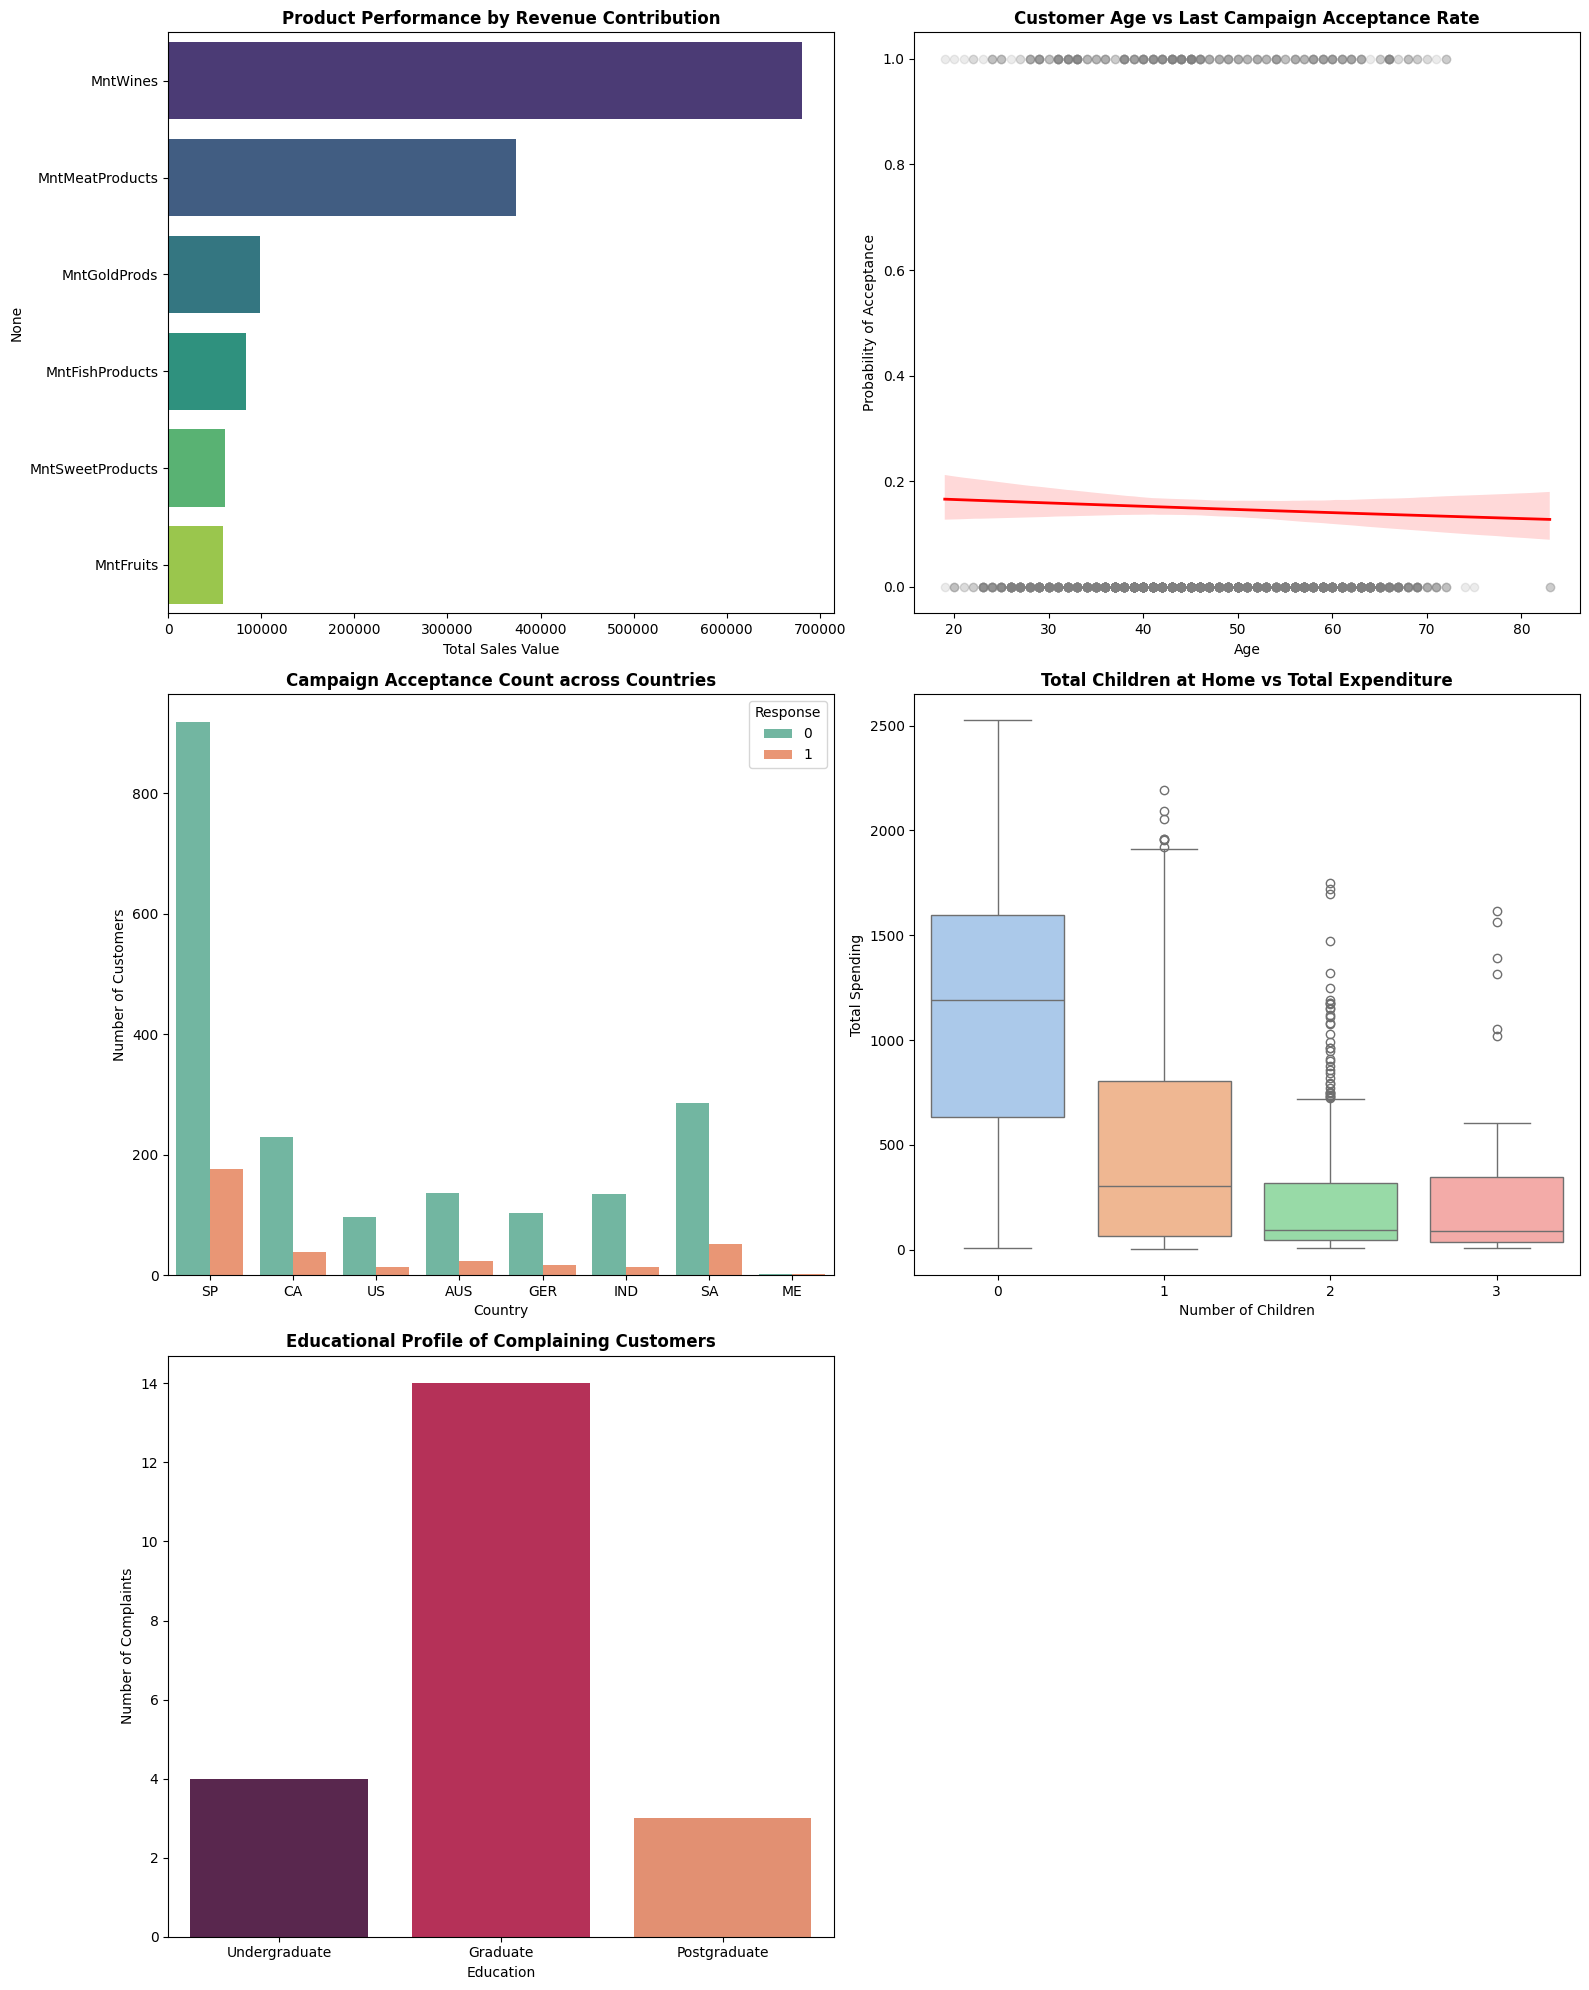

In [9]:
# Create a large grid layout for 5 distinct business charts
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Product Performance Analysis
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_totals = df[product_cols].sum().sort_values(ascending=False)
sns.barplot(x=product_totals.values, y=product_totals.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Product Performance by Revenue Contribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Sales Value')

# 2. Age vs Campaign Acceptance Rate
sns.regplot(x='Age', y='Response', data=df, logistic=True, ax=axes[0, 1], 
            scatter_kws={'alpha':0.15, 'color': 'gray'}, line_kws={'color':'red', 'linewidth': 2})
axes[0, 1].set_title('Customer Age vs Last Campaign Acceptance Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Probability of Acceptance')

# 3. Campaign Performance Across Countries
sns.countplot(x='Country', hue='Response', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Campaign Acceptance Count across Countries', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')

# 4. Expenditure Patterns Based on Children at Home
sns.boxplot(x='Total_Children', y='Total_Spending', data=df, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Total Children at Home vs Total Expenditure', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Children')
axes[1, 1].set_ylabel('Total Spending')

# 5. Profile of Customers Who Complained
complainers = df[df['Complain'] == 1]
sns.countplot(x='Education', data=complainers, ax=axes[2, 0], palette='rocket', 
              order=['Undergraduate', 'Graduate', 'Postgraduate'])
axes[2, 0].set_title('Educational Profile of Complaining Customers', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Number of Complaints')

# Remove the empty 6th subplot grid space to make it look clean
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()